# Импорт библиотек 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/Users/veronikakozlova/Documents/ВКР HSE /Кофе молотый.xlsx')

# Матрица корреляции для числовых признаков

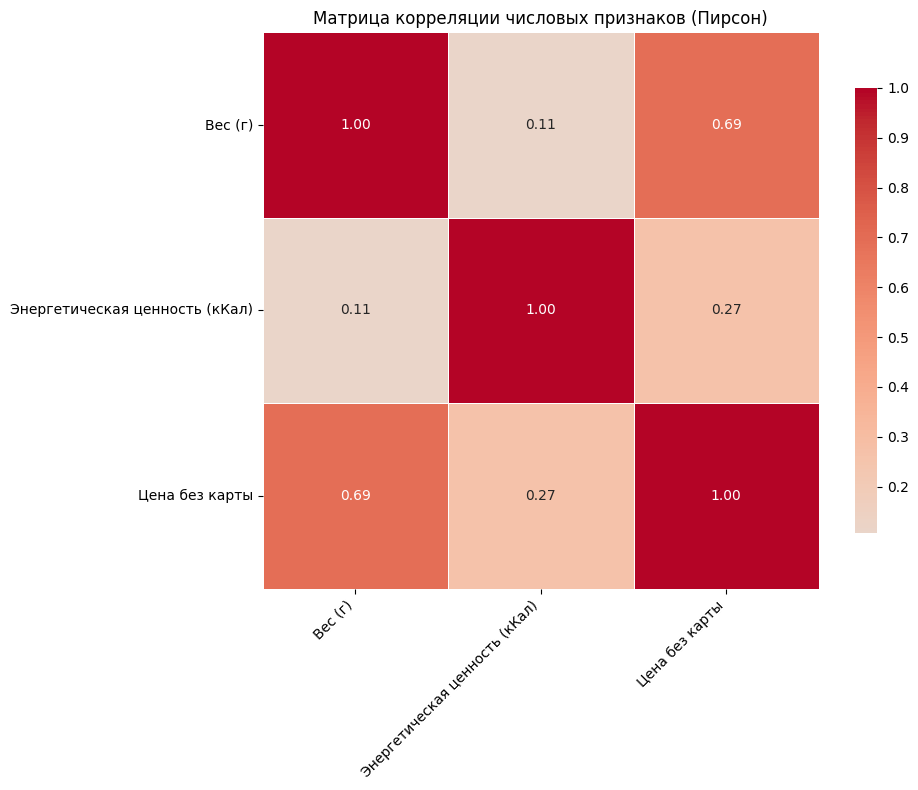

In [ ]:

# Список всех числовых признаков
numeric_all = [
    "Вес (г)",
    "Энергетическая ценность (кКал)",
    "Цена без карты",
]

# Проверка, что все столбцы существуют в df
existing_numeric = [col for col in numeric_all if col in df.columns]

# Вычисление корреляционной матрицы
corr_matrix = df[existing_numeric].corr(method='pearson')  # можно также spearman

# Построение тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,           # отображать значения
    fmt=".2f",            # формат чисел
    cmap="coolwarm",      # цветовая схема
    center=0,             # центр в нуле для контраста
    square=True,          # квадратные ячейки
    linewidths=0.5,       # линии между ячейками
    cbar_kws={"shrink": 0.8}  # размер цветовой шкалы
)
plt.title('Матрица корреляции числовых признаков (Пирсон)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

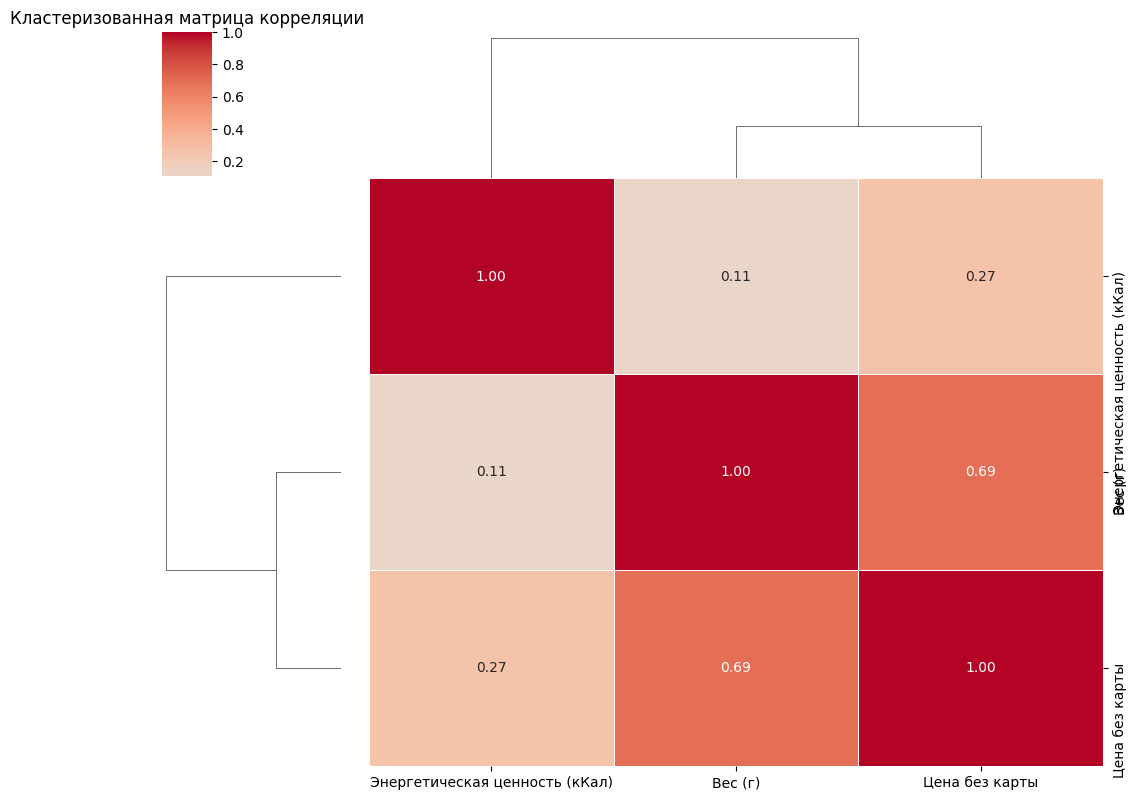

In [4]:
sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    figsize=(10, 8)
)
plt.title('Кластеризованная матрица корреляции')
plt.show()

# Кластеризация

In [ ]:

# Выбор переменных на вход кластеризации

numeric_features = [
    "Вес (г)",
    "Цена без карты",
]

categorical_features = [
    "Степень помола",
    "Интенсивность",
    "страна", 
    "Степень обжарки/ферментации"
]

# Препроцессинг

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# KMeans

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("cluster", KMeans(n_clusters=4, random_state=42, n_init=10))
])

df["Кластер"] = pipeline.fit_predict(df)

# Анализ кластеров

cluster_summary_numeric = df.groupby("Кластер")[numeric_features].mean()

print("Средние числовые показатели по кластерам:")
print(cluster_summary_numeric)

print("\nРазмеры кластеров:")
print(df["Кластер"].value_counts())



Средние числовые показатели по кластерам:
             Вес (г)  Цена без карты
Кластер                             
0         257.095238       950.16381
1          66.730769       412.48000
2         230.750000       637.59200
3        1000.000000      1999.99000

Размеры кластеров:
Кластер
0    42
2    40
1    26
3     1
Name: count, dtype: int64


# Метод локтя

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

# Диапазон количества кластеров
k_range = range(1, 11)

inertias = []

for k in k_range:
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),  # тот же ColumnTransformer
        ("cluster", KMeans(n_clusters=k, random_state=42, n_init=10))
    ])
    
    pipeline.fit(df)
    
    inertias.append(pipeline.named_steps["cluster"].inertia_)

# Построение графика
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Количество кластеров (k)")
plt.ylabel("Inertia (WSS)")
plt.title("Метод локтя для выбора числа кластеров")
plt.xticks(k_range)
plt.show()

# Проверка качества

In [ ]:

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

X_transformed = preprocessor.fit_transform(df)

# Обучаем модель (например, k=4 — как в основном анализе)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_transformed)

# Преобразование в плотный массив
if hasattr(X_transformed, "toarray"):
    X_dense = X_transformed.toarray()
else:
    X_dense = X_transformed

sil_score = silhouette_score(X_dense, labels)
db_index = davies_bouldin_score(X_dense, labels)
ch_index = calinski_harabasz_score(X_dense, labels)
inertia = kmeans.inertia_

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_index)
print("Calinski-Harabasz Index:", ch_index)
print("Inertia:", inertia)

Silhouette Score: 0.20784489335542178
Davies-Bouldin Index: 1.3237827209530137
Calinski-Harabasz Index: 31.118693478028558
Inertia: 210.3320559194996


# Визуализация

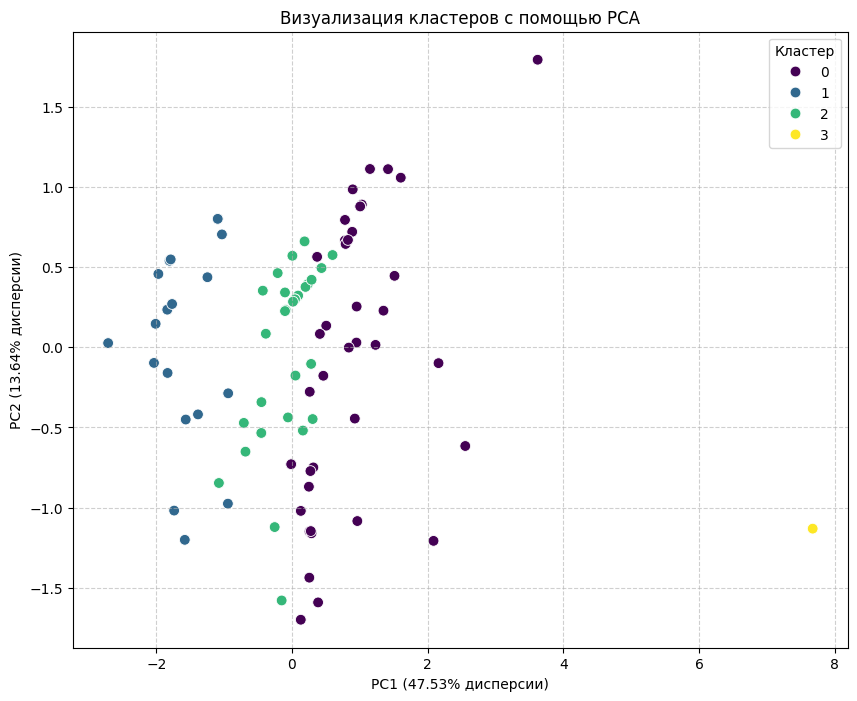

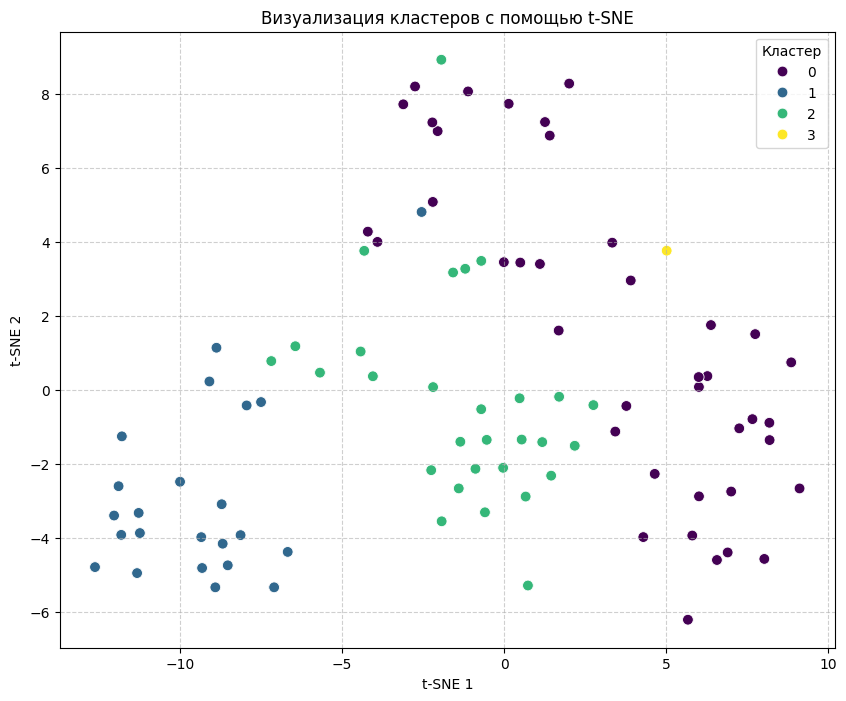

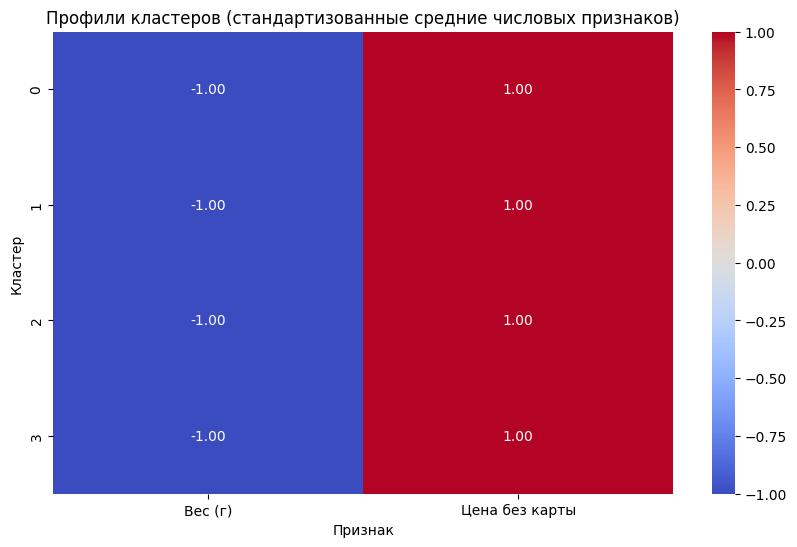

/var/folders/c_/kz000cy95_d9qk4m43x2b4t80000gn/T/ipykernel_19490/1811874858.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Кластер', y=feat, ax=axes[i], palette='viridis', errorbar=None)
/var/folders/c_/kz000cy95_d9qk4m43x2b4t80000gn/T/ipykernel_19490/1811874858.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Кластер', y=feat, ax=axes[i], palette='viridis', errorbar=None)


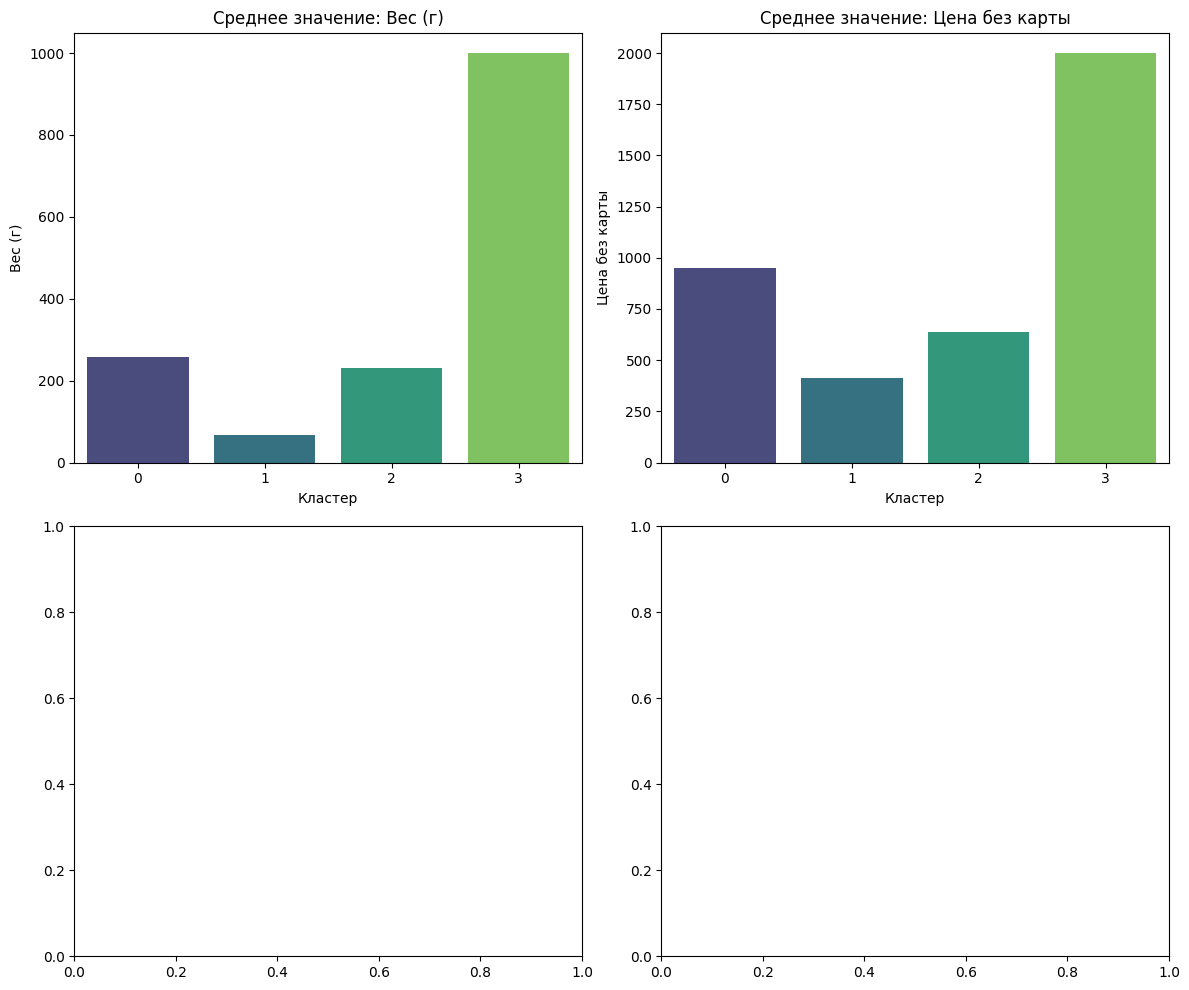

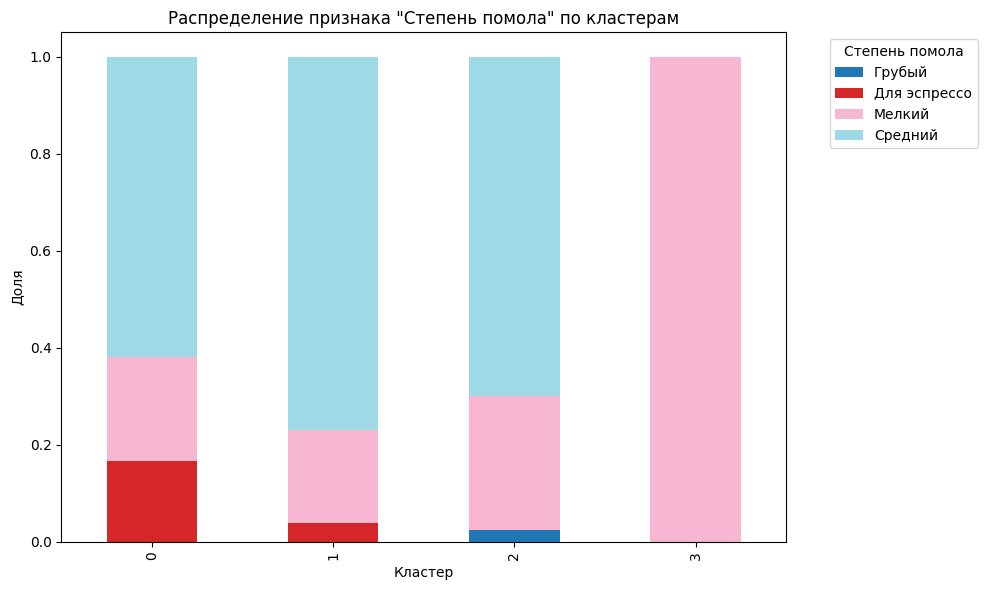

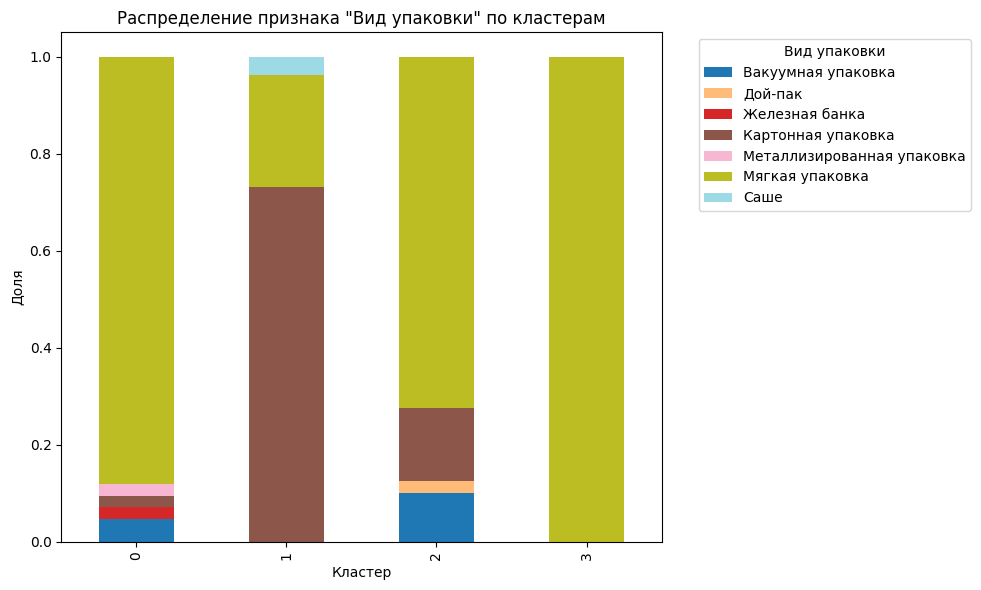

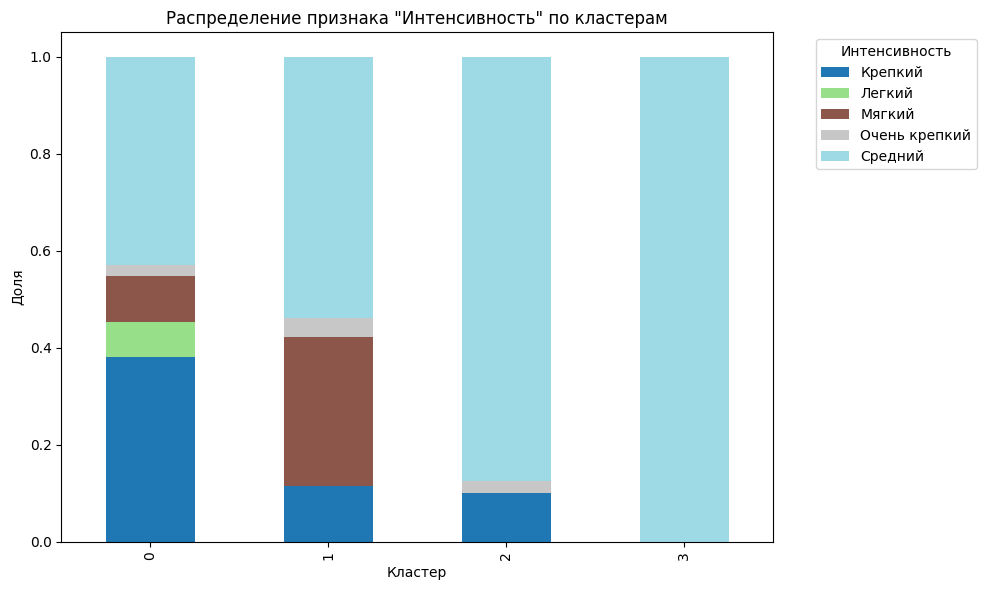

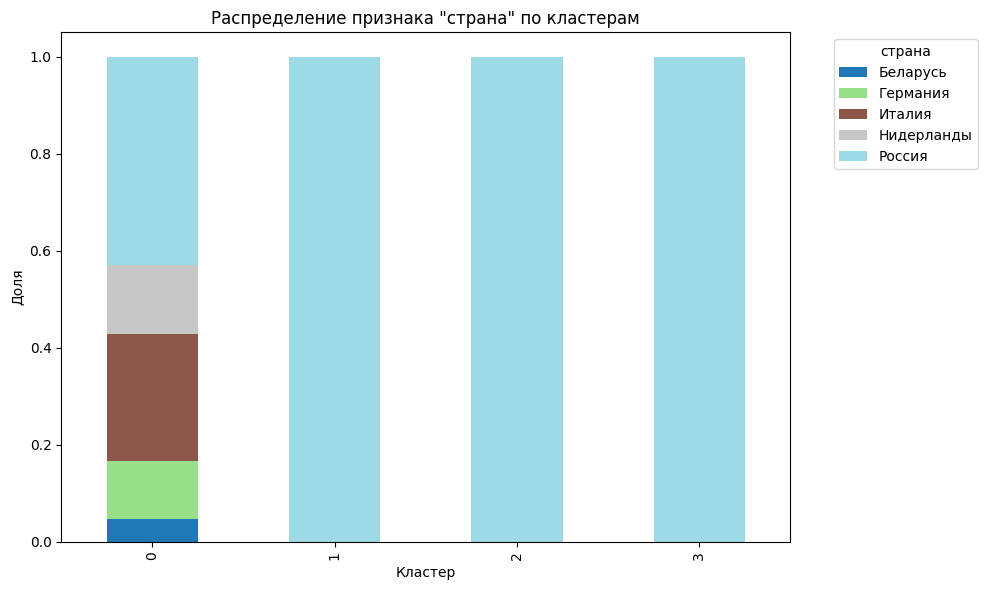

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE  # альтернативно для более качественной визуализации
import pandas as pd
import numpy as np

X_transformed = preprocessor.fit_transform(df)

# PCA
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_transformed)

#  DataFrame 
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Кластер'] = df['Кластер'].values

# Построение scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Кластер', palette='viridis', s=60)
plt.title('Визуализация кластеров с помощью PCA')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} дисперсии)')
plt.legend(title='Кластер')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Визуализация с t-SNE для более чёткого разделения
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_transformed)

tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['Кластер'] = df['Кластер'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Кластер', palette='viridis', s=60)
plt.title('Визуализация кластеров с помощью t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Кластер')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Профили кластеров по числовым признакам

# Нормализация средних значений
numeric_features = [
    "Вес (г)",
    "Цена без карты"
]

# Вычисление средних по кластерам
cluster_means = df.groupby('Кластер')[numeric_features].mean()

# Стандартизация средних (Z-score)/ MinMax
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cluster_means_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_means.T).T,  # транспонируем, чтобы масштабировать по строкам?
    columns=numeric_features,
    index=cluster_means.index
)

# Тепловая карта
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means_scaled, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Профили кластеров (стандартизованные средние числовых признаков)')
plt.xlabel('Признак')
plt.ylabel('Кластер')
plt.show()

# столбчатая диаграмма
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for i, feat in enumerate(numeric_features):
    sns.barplot(data=df, x='Кластер', y=feat, ax=axes[i], palette='viridis', errorbar=None)
    axes[i].set_title(f'Среднее значение: {feat}')
    axes[i].set_xlabel('Кластер')
plt.tight_layout()
plt.show()

# Профили кластеров по категориальным признакам

categorical_features = [
    "Степень помола",
    "Вид упаковки",
    "Интенсивность",
    "страна"
]

for cat in categorical_features:
    # Таблица сопряжённости: кластеры vs категории
    crosstab = pd.crosstab(df['Кластер'], df[cat], normalize='index')  # нормализация по строкам (внутри кластера)
    
    # Визуализация в виде stacked bar chart
    crosstab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
    plt.title(f'Распределение признака "{cat}" по кластерам')
    plt.xlabel('Кластер')
    plt.ylabel('Доля')
    plt.legend(title=cat, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
df.to_excel('/Users/veronikakozlova/Documents/ВКР HSE /кластеры-кофе_new.xlsx')